<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Özlem Salehi Köken
        </td>        
</tr></table>

# Quantum Approximate Optimization Algorithm - Implementation


In the previous notebook, we learnt about the basics of QAOA. In this notebook, we will learn about implementation.

## How to implement QAOA?


Implementation of QAOA consist of three parts:

- Initial state
- Mixer Hamiltonian
- Cost Hamiltonian

### Initial state

Since the initial state is $\ket{+}^n$, we can implement it by applying $H$ to all qubits.

### Task 1

Complete the function below that creates the initial state given the number of qubits in the circuit.


In [ ]:
from qiskit import  QuantumCircuit

def initial_state(n):
  ### Your code here


  return qc

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task1)

### Mixer Hamiltonian

The mixer Hamiltonian is defined as $H_B = -\sum_{j=1}^n X_j$ and the corresponding unitary at layer $i$ is given by $$U (H_B , \beta_i) = exp(-i \beta_i H_B).$$

The Hamiltonian
$H_B = -\sum_{i=1}^n X_i$
  consists of Pauli
$X$-operators acting on each qubit. Using the identities from the previous notebook, we can express it as

$$ U (H_B , \beta_i) = exp(-i \beta_i H_B) = \prod_{j=1}^n R_{x_j}(-2\cdot \beta_i). $$

Note that the $-$ sign inside $R_{x_j}(.)$ can be omitted as it can be hidden inside $\beta$.


<figure>
    <img src='../images/mixer.png' />
</figure>


### Task 2

Complete the function below that creates the mixer given the number of qubits in the circuit. The function takes the number of qubits and the layer number as input. The circuit should be parametrized by $\beta_i$ where $i$ is the layer number.



In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def mixer(n, i):
  ### Your code here


  return qc

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task2)

### Cost Hamiltonian

In QAOA, the cost Hamiltonian is diagonal and consists of $Z$ terms only. Here is an example cost Hamiltonian:

$$H_C = Z_0Z_1+3Z_1Z_2  + 2Z_0Z_2 -Z_1 + 3Z_2.$$

It is common to have Hamiltonians that consist of terms that act on at most two qubits i.e., 2-local (the reason will be explained in the following notebook), but in QAOA one can also implement multi-qubit interactions. For simplicity, let us assume that our Hamiltonian is 2-local. In that case, $H_C$ takes the following form:

$$H_C = \sum_i h_i Z_i + \sum_{i,j} J_{ij} Z_i Z_j.$$

Note that single-qubit $Z$ terms and 2-qubit terms commute. Therefore, we can use the identity $exp(A+B) = exp(A)exp(B)$. Hence, the corresponding unitary is given by

\begin{align}
U(H_C, \gamma_p) &= exp(-i\gamma_p H_C) \\
&= exp(-i\gamma_p \sum_i h_i Z_i )exp(-i\gamma_p \sum_{i,j} J_{ij} Z_i Z_j)\\
&= \prod_{i}R_{Z_i}(2\cdot h_{i}\gamma_p )\prod_{i,j}R_{Z_iZ_j}(2\cdot J_{ij}\gamma_p ).\end{align}

$R_{ZZ}(\theta)$ is a 2-qubit rotation around $Z$ defined as

$$
R_{ZZ}(\theta) := exp\left(-i \frac{\theta}{2} Z \otimes Z\right ) = \begin{pmatrix}
e^{-i \frac{\theta}{2}} & 0 & 0 & 0 \\
0 & e^{i \frac{\theta}{2}} & 0 & 0 \\
0 & 0 & e^{i \frac{\theta}{2}} & 0 \\
0 & 0 & 0 & e^{-i \frac{\theta}{2}}
\end{pmatrix}
.
$$

Such rotation is implemented as follows.



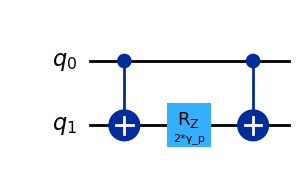

In Qiskit, it can be directly implemented by `rzz` gate.

To understand why this circuit implements the required rotation let's go step by step.

**Step 1: Eigenvalues of $Z_0Z_1$**

Acting on a computational basis state:

$$Z_0 Z_1 |x_0 x_1\rangle = (-1)^{x_0 + x_1} |x_0 x_1\rangle.$$

The four cases are:

$$Z_0Z_1|00\rangle = +|00\rangle, \quad Z_0Z_1|01\rangle = -|01\rangle, \quad Z_0Z_1|10\rangle = -|10\rangle, \quad Z_0Z_1|11\rangle = +|11\rangle.$$

The eigenvalue is $+1$ when $x_0$ and $x_1$ are equal, and $-1$ when they differ — i.e., it depends only on the parity $x_0 \oplus x_1$.

**Step 2: What the rotation does**

$$e^{-i\gamma Z_0 Z_1}|x_0 x_1\rangle = e^{-i\gamma (-1)^{x_0 \oplus x_1}}|x_0 x_1\rangle.$$

Each basis state picks up a phase $e^{i\gamma}$ if $x_0 = x_1$, and $e^{-i\gamma}$ if $x_0 \neq x_1$.

**Step 3: The CNOT implements this**

Applying $CNOT$ copies the parity into qubit 1:

$$|x_0, x_1\rangle \longmapsto |x_0,\, x_0 \oplus x_1\rangle.$$

Applying $R_z(2\gamma)$ to qubit 1 then gives:

$$R_z(2\gamma)|x_0 \oplus x_1\rangle = e^{-i\gamma(-1)^{x_0 \oplus x_1}}|x_0 \oplus x_1\rangle,$$

which attaches exactly the phase we want. Finally, applying CNOT again restores qubit 1:

$$|x_0,\, x_0 \oplus x_1\rangle \longmapsto |x_0,\, x_1\rangle.$$

The full circuit $CNOT(0,1) \to R_z(2\gamma) \to CNOT(0,1)$ therefore implements $e^{-i\gamma Z_0 Z_1}$
on every computational basis state, which is precisely the $R_{ZZ}$ gate.

### Task 3

Complete the function below that implements ansatz for the given cost Hamiltonian which is guaranteed to be 2-local. The function takes the number of qubits, the Hamiltonian, and the layer number as input. The circuit should be parametrized by $\gamma_i$, where $i$ is the layer number.

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):

  ### Your code here

  return qc

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task3)

The construction can be generalized to multiple qubits. Here are some examples.

- Circuit for the term $Z_0Z_1Z_2Z_3$:

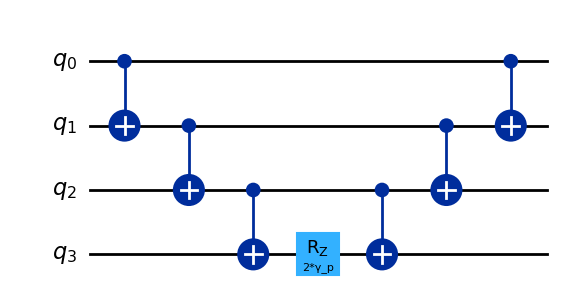

- Circuit for the term $Z_0Z_2Z_3$:

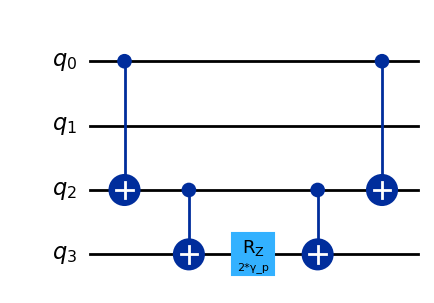

### Task 4

Extend the function you have written in Task 3 by also taking into account Hamiltonians which are not 2-local.

In [ ]:
from qiskit import  QuantumCircuit
from qiskit.circuit import Parameter

def cost(n, op, i):
  ### Your code here

  return qc

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task4)


### Task 5

For the Hamiltonian $H= 2ZZZI + 4IZZI + IIIZ + ZIIZ$, verify the correctness of the circuit construction you made in Task 4, by exact diagonalization. Note that the function `cost` returns a parametrized circuit and you should assign parameters before obtaining the unitary circuit. Assume that we are in the first layer and assign $\gamma_0=1$

In [ ]:
from qiskit.quantum_info import SparsePauliOp

H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
qc = cost(4,H,0)

### Your code here

In [ ]:
import numpy as np
from scipy.linalg import eig

### Your code here

U2 = P @ expD @ P_inv

In [ ]:
assert np.allclose(U1,U2)

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task5)

### Cost function


Let us recall how the cost Hamiltonian is defined:

$$
H_C \ket{x} = f(x) \ket{x}.
$$

The cost function $f(x)$ depends on the problem we want to optimize.

Circuit measurement yields us a bit string $x'$ which encodes a solution to the problem. Using this bit string, one can calculate the corresponding cost $f(x')$. This is needed to estimate the expectation value of $H_C$ from the measurement results.

Let us give an example.

Consider the Max-Cut problem. Given a graph, the problem requires splitting the vertices/nodes into two disjoint groups so that there are as many edges as possible between the groups. The partition of two adjacent vertices into disjoint sets is called a cut. The goal of this problem is to find a cut that contains the maximum number of edges.

Let us encode the solution space of this problem using bit strings. Suppose that, for a bit string $x_1x_2\cdots x_n$,
- Node $i$ belongs to group 0 if $x_i=0$,
- Node $i$ belongs to group 1 if $x_i=1$.

Given a bit string, we should be able to count the number of edges in the cut and determine the associated cost. An edge belongs to the cut if its endpoints belong to different groups. For two vertices $i$ and $j$,

$$(i,j) \text{ belongs to the cut if } x_i+x_j - 2x_ix_j = 1.$$

So a summation over all edges $E$ in the graph gives us the number of edges in the cut:

$$
\sum_{(i,j)\in E} x_i+x_j - 2x_ix_j.
$$

Since in QAOA we are trying to minimize the cost function, we put a $-$ sign to get the cost function.

$$
f(x) = - \left(\sum_{(i,j)\in E} x_i+x_j - 2x_ix_j\right ).
$$

  This is how we can define our cost function for the Max-Cut problem.

## The algorithm

Let us put the pieces together now. We denote the parameters at iteration $i$ by $(\gamma^i, \beta^i)$.

- We construct our ansatz $\prod_{i=1}^p exp(-i \beta_i H_B)exp(-i \gamma_i H_C)\ket{+}^n$.

- We initialize its parameters to obtain $\ket{\psi(\gamma^0, \beta^0)}$.
- We use a classical optimizer to adjust the parameters ${\gamma}$ and $\beta$ to minimize our cost function. The cost function is computed by the outcomes of the measurement results and its minimization corresponds to minimization of
$\bra{\psi(\gamma, \beta)}H_C\ket{\psi(\gamma, \beta)}$.

QAOA is a hybrid algorithm, where the optimization of the parameters is performed on a classical computer, and the quantum computer is used for computing the cost function.


<figure>
    <img src='../images/qaoa.png' />
</figure>


## What else about QAOA?

Some Advantages of QAOA for NISQ Devices:

- Near-Term Applicability: QAOA is designed for near-term quantum devices as it doesn't require full fault tolerance and can be run with relatively shallow circuits.

- Problem-Specific Ansatz: QAOA can be tailored to specific optimization problems by adjusting the structure of the quantum circuits, making it a good fit for a wide variety of combinatorial optimization problems.

- Hybrid Approach: Like VQE, QAOA is a hybrid quantum-classical algorithm, with the quantum device handling the quantum part and a classical computer performing the optimization.



Some Disadvantages of QAOA:

- Measurement Overhead: Similar to VQE, QAOA requires many measurements to estimate the expectation values of operators, resulting in significant measurement overhead, which can increase the time and cost of the computation.

- Optimization Challenges: The optimization process in QAOA can be challenging, especially due to issues like barren plateaus or the difficulty of navigating the complex cost landscape with classical optimization methods.

- Ansatz Depth Trade-offs: The performance of QAOA improves with deeper circuits (more layers of quantum gates), but deeper circuits are difficult to implement on NISQ devices due to gate errors and noise. Additionally, deeper circuits might not always provide a significant improvement in optimization performance.



### Task 6

For the Hamiltonian $H= 2ZZZI + 4IZZI + IIIZ + ZIIZ$, create its QAOA circuit with 5 layers and draw it.

In [ ]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

n = 4
p = 5
H =  SparsePauliOp(["ZZZI","IZZI","IIIZ", "ZIIZ"], [2,4,1,1])
#Create the circuit

#Add initial state

qc.barrier()
for i in range(p):
  # Add mixer

  qc.barrier()
  # Add cost Hamiltonian

  qc.barrier()
qc.decompose().draw(output="mpl")

[click for our solution](02_qaoa_implementation_solutions.ipynb#Task6)